# Windy Gridworld Solver using SARSA
This notebook implements and solves the **Windy Gridworld** environment (Example 6.5) from Chapter 6 of the textbook *Reinforcement Learning: An Introduction* by Sutton & Barto (2nd Edition).

We use **SARSA**, an on-policy Temporal Difference learning algorithm, to learn the optimal action sequence to navigate the grid. This environment features upward wind forces in specific columns that push the agent off its intended path.


# Theoretical Framework: Temporal Difference Learning

## SARSA: On-Policy TD Control
We use **SARSA** (State-Action-Reward-State-Action), an **on-policy** Temporal Difference (TD) control algorithm, to solve the Windy Gridworld control problem.

Unlike Monte Carlo methods, which require completing an entire episode to update value estimates, TD methods bootstrap: they update estimates based on other learned estimates at each step.

![image (1).png](<attachment:image (1).png>)

### The Update Rule
SARSA estimates the action-value function $Q(s, a)$, which represents the expected return starting from state $s$, taking action $a$, and following the current policy $\pi$ thereafter. The update rule is applied after every time step $t$:

$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \left[ R_{t+1} + \gamma Q(S_{t+1}, A_{t+1}) - Q(S_t, A_t) \right]$$

Where:
* $S_t, A_t$ are the current state and action.
* $R_{t+1}$ is the observed reward.
* $S_{t+1}, A_{t+1}$ are the next state and next action chosen by the policy.
* $\alpha$ is the learning rate (step size).
* $\gamma$ is the discount factor.

SARSA is strictly **on-policy** because it updates estimates based on the action $A_{t+1}$ actually selected by the current behavioral policy (e.g., $\epsilon$-greedy), rather than assuming greedy action selection.

---

## Off-Policy SARSA Control
In the off-policy version of SARSA, the agent learns the action-value function $Q(s, a)$ for a target policy $\pi$ while behaving according to a different behavior policy $b$ (e.g., $\epsilon$-greedy exploration).

Because the actions are selected according to the behavior policy $b$, we must correct for the difference in probabilities using the **importance sampling ratio**:
$$\rho_{t} \doteq \frac{\pi(A_t \mid S_t)}{b(A_t \mid S_t)}$$

### The Off-Policy Update Rule
The off-policy SARSA update rule scales the TD error by the importance sampling ratio of the next transition step:

$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \rho_{t+1} \left[ R_{t+1} + \gamma Q(S_{t+1}, A_{t+1}) - Q(S_t, A_t) \right]$$

Where $\rho_{t+1} = \frac{\pi(A_{t+1} \mid S_{t+1})}{b(A_{t+1} \mid S_{t+1})}$ is the importance sampling ratio for the action $A_{t+1}$ chosen at the next state $S_{t+1}$. If $A_{t+1}$ is not an action that the target policy would take (i.e., $\pi(A_{t+1} \mid S_{t+1}) = 0$), the ratio becomes 0, and the estimate is not updated.


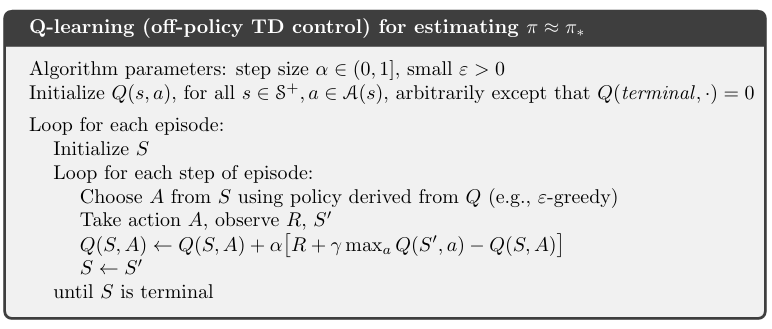

## The Windy Gridworld Environment

### State and Action Space
The state space $\mathcal{S}$ is a discrete grid of size $10 \times 7$:
$$\mathcal{S} = \{ (x, y) \mid x \in \{0, \dots, 9\}, y \in \{0, \dots, 6\} \}$$

The agent starts at $S_{\text{start}} = (0, 3)$ and must reach the terminal state $S_{\text{goal}} = (7, 3)$.

The action space $\mathcal{A}$ consists of four standard movements:
$$\mathcal{A} = \{ \text{Right (0), Left (1), Up (2), Down (3)} \}$$



### System Dynamics (Wind)
The transition dynamics are deterministic but include a "wind" force that shifts the agent upward depending on the column index. If the agent is in state $(x, y)$ and chooses an action resulting in position $(x', y')$, the wind applies an additional shift $w(x)$ based on the column the agent is transitioning *from*:
$$y_{\text{final}} = y' + w(x)$$

The wind intensity $w(x)$ for the columns $x=0$ to $x=9$ is defined as:
$$W = [0, 0, 0, 1, 1, 1, 2, 2, 1, 0]$$

### Reward Signal
The reward system encourages the agent to find the shortest path:
$$R_t = \begin{cases} 0 & \text{if } S_{t+1} = S_{\text{goal}} \\ -1 & \text{otherwise} \end{cases}$$


### 1. Environment Definition


In [1]:
import numpy as np

class GridWorldEnv:
    def __init__(self):
        self.width = 10
        self.height = 7
        self.start_pos = (0, 3)
        self.goal_pos = (7, 3)
        self.agent_pos = self.start_pos

        # Wind values for columns 0-9
        self.column_dynamics = [0, 0, 0, 1, 1, 1, 2, 2, 1, 0]

    def reset(self):
        self.agent_pos = self.start_pos
        return self.agent_pos

    def step(self, action):
        curr_x, curr_y = self.agent_pos

        # 1. Determine Wind Force (applies to the current step)
        wind = self.column_dynamics[curr_x]

        # 2. Determine Action Deltas
        dx, dy = 0, 0
        if action == 0:   # Right
            dx = 1
        elif action == 1: # Left
            dx = -1
        elif action == 2: # Up
            dy = 1
        elif action == 3: # Down
            dy = -1

        # 3. Calculate New Position
        # The agent is pushed by their own legs (dy) AND the wind (wind)
        next_x = curr_x + dx
        next_y = curr_y + dy + wind

        # 4. Clamp to Grid Boundaries
        # (Standard grid world physics: hitting a wall keeps you at the wall)
        next_x = max(0, min(next_x, self.width - 1))
        next_y = max(0, min(next_y, self.height - 1))

        # Update state
        self.agent_pos = (next_x, next_y)

        # 5. Check Terminal
        # Must land EXACTLY on the goal
        if self.agent_pos == self.goal_pos:
            return self.agent_pos, 0, True
        else:
            return self.agent_pos, -1, False


## SARSA Agent Implementation

### Action Selection ($\epsilon$-Greedy)
To balance exploration and exploitation, we use an $\epsilon$-greedy action selection strategy:
* With probability $\epsilon = 0.1$, the agent selects a random action.
* With probability $1 - \epsilon$, the agent selects the action corresponding to $\max_a Q(s, a)$.
Ties are broken randomly to avoid directional bias.

We use the standard hyperparameters:
* Learning rate $\alpha = 0.1$ (Decaying/low constant learning rate prevents value chattering for optimal convergence)
* Exploration rate $\epsilon = 0.1$
* Discount factor $\gamma = 1.0$ (Undiscounted episodic task)

### Data Structures
The action-values are stored in a tensor $\mathbf{Q} \in \mathbb{R}^{10 \times 7 \times 4}$, initialized to zero.


### 2. SARSA Agent Definition


In [2]:
import random

class SarsaAgent:
    def __init__(self, width=10, height=7, action_space=[0, 1, 2, 3]):
        self.width = width
        self.height = height
        self.actions = action_space

        # Initialization Parameters (alpha=0.1 matches Sutton & Barto page 130)
        self.alpha = 0.1      # Step size
        self.epsilon = 0.1    # Exploration rate
        self.gamma = 1.0      # Discount factor (undiscounted episodic task)

        # Initialize Q-values to 0
        self.Q = np.zeros((self.width, self.height, len(self.actions)))

    def choose_action(self, state):
        x, y = state

        # Exploration
        if np.random.rand() < self.epsilon:
            return np.random.choice(self.actions)

        # Exploitation (with random tie-breaking)
        else:
            q_values = self.Q[x, y, :]
            max_q = np.max(q_values)
            ties = np.where(q_values == max_q)[0]
            return np.random.choice(ties)

    def train(self, env, num_episodes=5000):
        print(f"Starting Training for {num_episodes} episodes...")

        for episode in range(num_episodes):
            state = env.reset()
            action = self.choose_action(state)
            done = False

            while not done:
                next_state, reward, done = env.step(action)
                next_action = self.choose_action(next_state)

                current_q = self.Q[state[0], state[1], action]
                next_q = self.Q[next_state[0], next_state[1], next_action]

                # SARSA Update
                target = reward + self.gamma * next_q
                self.Q[state[0], state[1], action] += self.alpha * (target - current_q)

                state = next_state
                action = next_action

        print("Training Completed.")


## Training the Agent and Recovering the Optimal Path
We now train the agent for 5000 episodes and trace the optimal path learned under the greedy policy (setting $\epsilon = 0$).


In [3]:
# Create environment and agent
env = GridWorldEnv()
agent = SarsaAgent()

# Train (5000 episodes is very quick and guarantees convergence)
agent.train(env, num_episodes=5000)

# Trace path
def get_optimal_path(env, agent):
    state = env.reset()
    path = [state]
    total_steps = 0
    max_steps = 100

    while state != env.goal_pos and total_steps < max_steps:
        x, y = state
        q_values = agent.Q[x, y, :]
        best_action = np.argmax(q_values)

        next_state, reward, done = env.step(best_action)
        path.append(next_state)
        state = next_state
        total_steps += 1

    return path

optimal_path = get_optimal_path(env, agent)
print(f"\nLearned Path Length: {len(optimal_path) - 1} steps")
print(f"Coordinate Sequence: {optimal_path}")


Starting Training for 5000 episodes...
Training Completed.

Learned Path Length: 15 steps
Coordinate Sequence: [(0, 3), (1, 3), (2, 3), (3, 3), (4, 4), (5, 5), (6, 6), (7, 6), (8, 6), (9, 6), (9, 5), (9, 4), (9, 3), (9, 2), (8, 2), (7, 3)]


## Path Animation
We visualize the agent's movement along the learned path using a simple, text-based animation.
* Emojis represent: `🔵` (Agent), `S ` (Start), `G ` (Goal), and `· ` (Empty cells).
* Wind intensities are indicated in the background of each column: `· ` (no wind), `↑ ` (wind=1), and `⇈ ` (wind=2).


In [6]:
from IPython.display import clear_output
import time

def animate_path(env, path):
    for step, state in enumerate(path):
        clear_output(wait=True)
        print(f"--- Steps: {step} / {len(path)-1} ---")
        grid = []
        for y in range(env.height - 1, -1, -1):
            row = []
            for x in range(env.width):
                if (x, y) == state:
                    row.append("🔵")  # Agent
                elif (x, y) == env.start_pos:
                    row.append("S ")
                elif (x, y) == env.goal_pos:
                    row.append("G ")
                else:
                    w = env.column_dynamics[x]
                    if w == 1:
                        row.append("↑ ")
                    elif w == 2:
                        row.append("⇈ ")
                    else:
                        row.append("· ")
            grid.append(" ".join(row))
        print("\n".join(grid))
        time.sleep(0.3)

# Play the animation of the learned path
animate_path(env, optimal_path)


--- Steps: 15 / 15 ---
·  ·  ·  ↑  ↑  ↑  ⇈  ⇈  ↑  · 
·  ·  ·  ↑  ↑  ↑  ⇈  ⇈  ↑  · 
·  ·  ·  ↑  ↑  ↑  ⇈  ⇈  ↑  · 
S  ·  ·  ↑  ↑  ↑  ⇈  🔵 ↑  · 
·  ·  ·  ↑  ↑  ↑  ⇈  ⇈  ↑  · 
·  ·  ·  ↑  ↑  ↑  ⇈  ⇈  ↑  · 
·  ·  ·  ↑  ↑  ↑  ⇈  ⇈  ↑  · 
